In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, roc_auc_score

In [2]:
df1= pd.read_excel('new_data_set.xlsx')
print(df1.shape)
df1.head()

(2233, 67)


,pid,facilityid,examinationdate,age,sex,ee_zn_myasthener_exazerbation,zn_myasthener_krise,age_erst,age_diag,time_erst_to_diag,...,japan_classification,ee_postinterventionstatus_rb,eomg_lomg_45,eomg_lomg_50,thymom,adl_pass,qmg_pass,qol_pass,ee_auswahlbildungsabschluss_rb,schwerbehinderung
0,00QM6V52,2019009,2023-01-31 00:00:00,34.961111,0,0.0,1,17.583333,17.750000,0.166667,...,1.0,5.0,0.0,0.0,0.0,1.0,1.0,NaN,1.0,2.0
1,06U8DLMD,2019006,2023-01-31 00:00:00,59.711111,1,0.0,0,55.750000,58.916667,3.166667,...,4.0,6.0,1.0,1.0,0.0,NaN,1.0,NaN,1.0,0.0
2,0D31R9UX,2019010,2023-07-19 00:00:00,83.344444,1,1.0,0,80.666667,80.916667,0.250000,...,4.0,7.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0
3,0DAJN5Y2,2019019,2023-01-17 00:00:00,56.505556,1,0.0,0,56.166667,56.250000,0.083333,...,4.0,6.0,1.0,1.0,0.0,NaN,1.0,NaN,0.0,0.0
4,0G1WYG21,2019004,2020-12-10 00:00:00,39.986111,0,NaN,0,21.083333,21.083333,0.000000,...,4.0,2.0,0.0,0.0,0.0,1.0,NaN,0.0,2.0,0.0


In [3]:
df = df1.drop(columns=["pid", "facilityid", "examinationdate"], errors="ignore")
df.head()

,age,sex,ee_zn_myasthener_exazerbation,zn_myasthener_krise,age_erst,age_diag,time_erst_to_diag,dauer,mgfaklassifikation_schlimmste_historisch,mgfaklassifikation_schlimmste_historisch_1bis5,...,japan_classification,ee_postinterventionstatus_rb,eomg_lomg_45,eomg_lomg_50,thymom,adl_pass,qmg_pass,qol_pass,ee_auswahlbildungsabschluss_rb,schwerbehinderung
0,34.961111,0,0.0,1,17.583333,17.750000,0.166667,17.377778,8.0,5.0,...,1.0,5.0,0.0,0.0,0.0,1.0,1.0,NaN,1.0,2.0
1,59.711111,1,0.0,0,55.750000,58.916667,3.166667,3.961111,2.0,2.0,...,4.0,6.0,1.0,1.0,0.0,NaN,1.0,NaN,1.0,0.0
2,83.344444,1,1.0,0,80.666667,80.916667,0.250000,2.677778,5.0,3.0,...,4.0,7.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0
3,56.505556,1,0.0,0,56.166667,56.250000,0.083333,0.338889,2.0,2.0,...,4.0,6.0,1.0,1.0,0.0,NaN,1.0,NaN,0.0,0.0
4,39.986111,0,NaN,0,21.083333,21.083333,0.000000,18.902778,5.0,3.0,...,4.0,2.0,0.0,0.0,0.0,1.0,NaN,0.0,2.0,0.0


In [4]:
def rf_feature_importance(df, target, test_size=0.2, random_state=42):
    data = df.dropna(subset=[target]).copy()

    # X, y
    X = data.drop(columns=[target])
    y = data[target]

    # Identify numeric and categorical columns
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    # Preprocess:
    # - numeric: median imputation
    # - categorical: most frequent imputation + one-hot encoding
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop"
    )

    # Model
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1
    )

    # Pipeline
    model = Pipeline(steps=[
        ("prep", preprocessor),
        ("rf", rf)
    ])

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Fit
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # AUC only works if y is binary and probabilities exist
    auc = None
    if len(np.unique(y_test)) == 2:
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)

    # --- Get feature names after preprocessing ---
    ohe = model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols) if len(cat_cols) > 0 else []
    feature_names = np.array(num_cols + list(cat_feature_names))

    # Feature importance
    importances = model.named_steps["rf"].feature_importances_
    fi = pd.DataFrame({"feature": feature_names, "importance": importances})
    fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)

    return model, fi, classification_report(y_test, y_pred, zero_division=0), auc

# Seronegative

In [5]:
model_sero, fi_sero, report_sero, auc_sero = rf_feature_importance(df, target="seronegative")

print("AUC:", auc_sero)
print(report_sero)

fi_sero.head(20)

AUC: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       325
         1.0       1.00      1.00      1.00        98

    accuracy                           1.00       423
   macro avg       1.00      1.00      1.00       423
weighted avg       1.00      1.00      1.00       423



,feature,importance
0,japan_classification,0.587773
1,age,0.032540
2,age_diag,0.030771
3,age_erst,0.028761
4,titinak,0.025475
5,ee_thymektomie_gr,0.022407
6,dauer,0.019401
7,time_erst_to_diag,0.019193
8,dekrement_testergebnis,0.018148
9,chronicfatigue_neu,0.017799


# gender

In [6]:
model_sex, fi_sex, report_sex, auc_sex = rf_feature_importance(df, target="sex")

print("AUC:", auc_sex)
print(report_sex)

fi_sex.head(20)

AUC: 0.7993927125506073
              precision    recall  f1-score   support

           0       0.71      0.79      0.75       247
           1       0.70      0.60      0.65       200

    accuracy                           0.71       447
   macro avg       0.71      0.70      0.70       447
weighted avg       0.71      0.71      0.71       447



,feature,importance
0,age_diag,0.080648
1,age_erst,0.077432
2,age,0.076103
3,dauer,0.057613
4,time_erst_to_diag,0.049138
5,scoreqol_neu,0.044298
6,chronicfatigue_neu,0.040018
7,scoreadl_neu,0.038352
8,ee_auswahlbildungsabschluss_rb,0.030383
9,ee_autoimmunerkrankungen_rbzu,0.030351


In [7]:
fi_sero.to_csv("feature_importance_seronegative.csv", index=False)
fi_sex.to_csv("feature_importance_sex.csv", index=False)

print("Saved feature importance tables.")

Saved feature importance tables.


In [8]:
with pd.ExcelWriter("feature_importance_results.xlsx", engine="openpyxl") as writer:
    fi_sero.to_excel(writer, sheet_name="Seronegativity", index=False)
    fi_sex.to_excel(writer, sheet_name="Sex", index=False)

print("Excel file saved: feature_importance_results.xlsx")

Excel file saved: feature_importance_results.xlsx


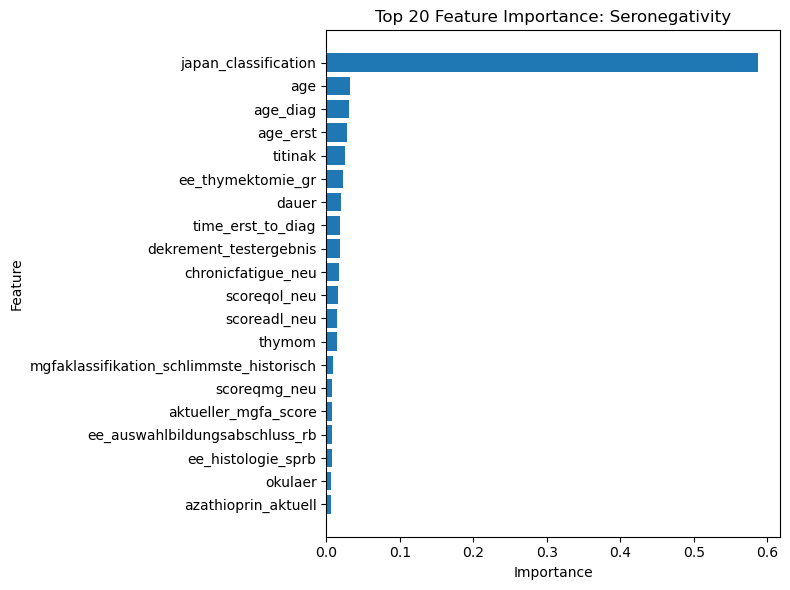

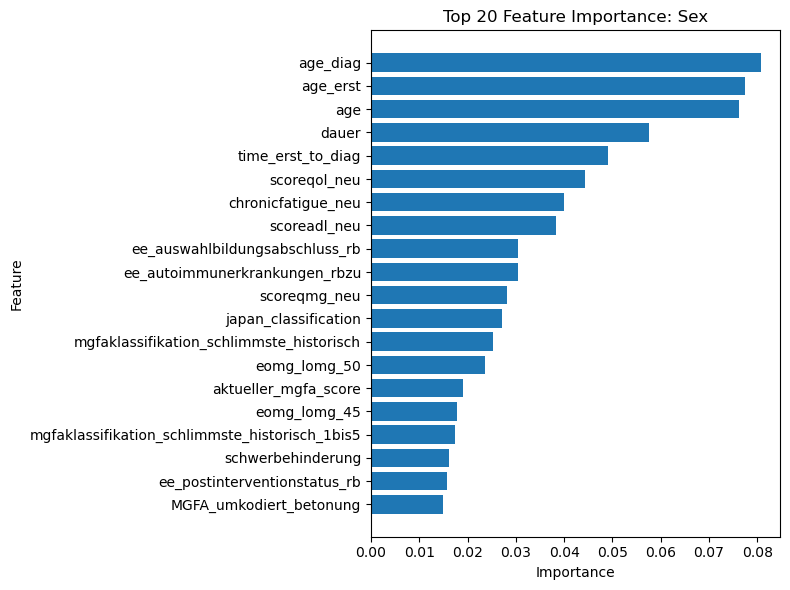

In [9]:
import matplotlib.pyplot as plt

def plot_top_features(fi, title, top_n=20):
    top = fi.head(top_n).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

plot_top_features(fi_sero, "Top 20 Feature Importance: Seronegativity")
plot_top_features(fi_sex, "Top 20 Feature Importance: Sex")

In [10]:
feature_name_map = {
    "age": "Current Age",
    "age_erst": "Age at Symptom Onset",
    "age_diag": "Age at Diagnosis",
    "dauer": "Disease Duration",
    "time_erst_to_diag": "Time from Symptom Onset to Diagnosis",

    "japan_classification": "Clinical Severity Classification",
    "mgfaklassifikation_schlimmste_historisch": "Worst Historical MGFA Classification",
    "mgfaklassifikation_schlimmste_historisch_1bis5": "Worst Historical MGFA Class (1–5)",
    "aktueller_mgfa_score": "Current MGFA Score",
    "MGFA_umkodiert_betonung": "MGFA Classification (Re-coded)",

    "scoreqmg_neu": "Quantitative MG Score (QMG)",
    "scoreadl_neu": "Activities of Daily Living Score (ADL)",
    "scoreqol_neu": "Quality of Life Score (QOL)",
    "chronicfatigue_neu": "Chronic Fatigue Score",

    "dekrement_testergebnis": "Decrement Test Result",
    "eomg_lomg_45": "Early vs Late-Onset MG (45-Year Cutoff)",
    "eomg_lomg_50": "Early vs Late-Onset MG (50-Year Cutoff)",

    "titinak": "Titin Antibody Status",
    "thymom": "Presence of Thymoma",
    "ee_histologie_sprb": "Thymus Histology Result",
    "ee_thymektomie_gr": "Thymectomy Status",
    "ee_autoimmunerkrankungen_rbzu": "Other Autoimmune Diseases",

    "ee_postinterventionsstatus_rb": "Post-Intervention Clinical Status",
    "azathioprin_aktuell": "Current Azathioprine Treatment",
    "okulaer": "Ocular Myasthenia Gravis",
    "schwerbehinderung": "Severe Disability Status",

    "ee_auswahlbildungsabschluss_rb": "Educational Level"
}

In [11]:
def rename_features(fi, mapping_dict):
    fi = fi.copy()
    fi["feature_english"] = fi["feature"].map(mapping_dict)
    fi["feature_english"] = fi["feature_english"].fillna(fi["feature"])
    return fi

In [12]:
fi_sero_top20 = fi_sero.head(20)
fi_sero_top20_named = rename_features(fi_sero_top20, feature_name_map)

fi_sero_top20_named

,feature,importance,feature_english
0,japan_classification,0.587773,Clinical Severity Classification
1,age,0.032540,Current Age
2,age_diag,0.030771,Age at Diagnosis
3,age_erst,0.028761,Age at Symptom Onset
4,titinak,0.025475,Titin Antibody Status
5,ee_thymektomie_gr,0.022407,Thymectomy Status
6,dauer,0.019401,Disease Duration
7,time_erst_to_diag,0.019193,Time from Symptom Onset to Diagnosis
8,dekrement_testergebnis,0.018148,Decrement Test Result
9,chronicfatigue_neu,0.017799,Chronic Fatigue Score


In [13]:
fi_sex_top20 = fi_sex.head(20)
fi_sex_top20_named = rename_features(fi_sex_top20, feature_name_map)

fi_sex_top20_named

,feature,importance,feature_english
0,age_diag,0.080648,Age at Diagnosis
1,age_erst,0.077432,Age at Symptom Onset
2,age,0.076103,Current Age
3,dauer,0.057613,Disease Duration
4,time_erst_to_diag,0.049138,Time from Symptom Onset to Diagnosis
5,scoreqol_neu,0.044298,Quality of Life Score (QOL)
6,chronicfatigue_neu,0.040018,Chronic Fatigue Score
7,scoreadl_neu,0.038352,Activities of Daily Living Score (ADL)
8,ee_auswahlbildungsabschluss_rb,0.030383,Educational Level
9,ee_autoimmunerkrankungen_rbzu,0.030351,Other Autoimmune Diseases


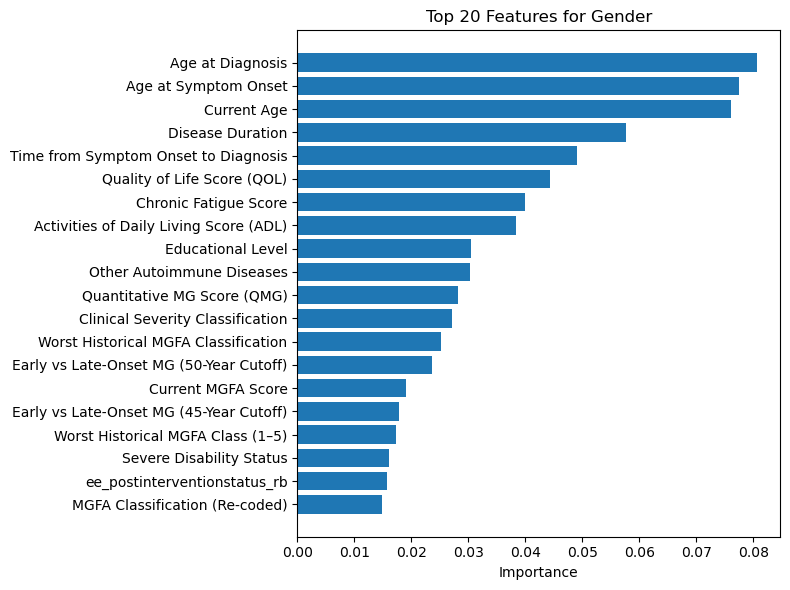

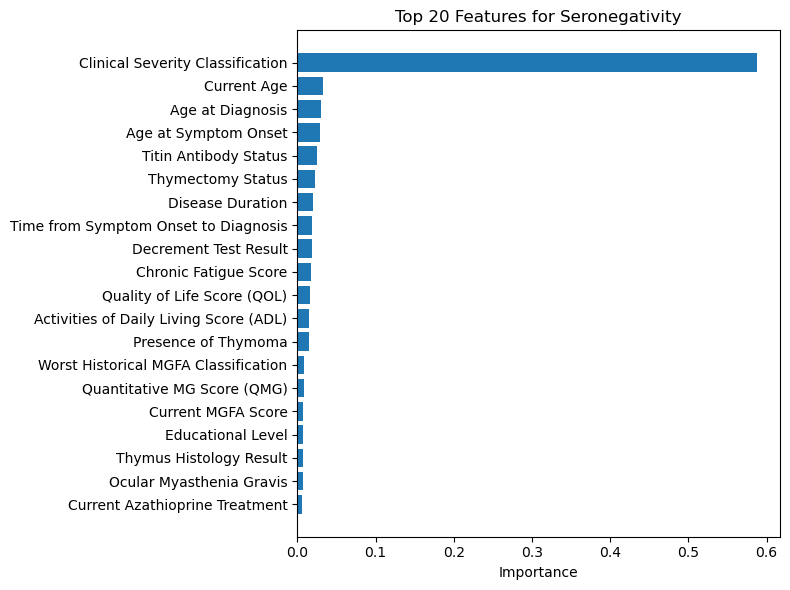

In [14]:
def plot_top_features_english(fi, title):
    fi = fi.iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(fi["feature_english"], fi["importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_features_english(fi_sex_top20_named, "Top 20 Features for Gender")
plot_top_features_english(fi_sero_top20_named, "Top 20 Features for Seronegativity")

In [15]:
final_table = fi_sero_top20_named[["feature_english", "importance"]].copy()

# Optional: rename columns for thesis presentation
final_table = final_table.rename(columns={
    "feature_english": "Feature",
    "importance": "Importance"
})

final_table

final_table.to_csv(
    "Top20_Feature_Importance_Seronegativity_English.csv",
    index=False
)

In [16]:
final_table_sex = fi_sex_top20_named[["feature_english", "importance"]].copy()
final_table_sex = final_table_sex.rename(columns={
    "feature_english": "Feature",
    "importance": "Importance"
})

final_table_sex.to_csv(
    "Top20_Feature_Importance_Sex_English.csv",
    index=False
)